<a href="https://colab.research.google.com/github/rizkyhaksono/llm-vs-slm-lab/blob/main/02-inference-perbandingan/04_benchmark_side_by_side.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02.04 — Benchmark Side-by-Side: LLM vs SLM fp32 vs SLM Q4

**Tujuan**: jalankan **10 prompt yang sama** di 3 backend, tabulasi hasil: latency, output tokens, biaya. Ini notebook "puncak" modul 02 — mengubah intuisi jadi angka.

**Prasyarat**: notebook 02.01, 02.02, 02.03 lulus (semua model sudah pernah loaded).

**Protokol**: tiap prompt jalan 3x per backend, ambil **median** latency. Output untuk display ambil dari run terakhir.

## 0. Bootstrap (jalankan pertama)

In [1]:
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    REPO_NAME = "llm-vs-slm-lab"
    REPO_URL = "https://github.com/rizkyhaksono/llm-vs-slm-lab.git"
    if not Path(REPO_NAME).exists():
        !git clone {REPO_URL}
    %cd {REPO_NAME}
    !pip install -q torch --index-url https://download.pytorch.org/whl/cpu
    !pip install -q -r requirements.txt

repo_root = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "requirements.txt").exists():
        repo_root = candidate
        break
assert repo_root is not None
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
print(f"IN_COLAB={IN_COLAB}, repo_root={repo_root}")

Cloning into 'llm-vs-slm-lab'...
remote: Enumerating objects: 95, done.
remote: Counting objects: 100% (95/95), done.
remote: Compressing objects: 100% (81/81), done.
remote: Total 95 (delta 32), reused 58 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (95/95), 158.53 KiB | 5.47 MiB/s, done.
Resolving deltas: 100% (32/32), done.
/content/llm-vs-slm-lab
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 MB 12.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 260.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 113.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.8/118.8 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.4/107.4 

## 1. Setup: 10 prompt + 3 backend

In [2]:
PROMPTS = [
    "Apa ibu kota Indonesia?",
    "Tuliskan 3 manfaat olahraga.",
    "Jelaskan apa itu inflasi dalam 2 kalimat.",
    "Berikan 5 nama buah tropis.",
    "What is 7 times 8? Answer with one number only.",
    "Terjemahkan ke English: 'Saya suka makan rendang'.",
    "Apa beda machine learning dan deep learning, singkat saja.",
    "Buatkan 1 pantun tentang belajar coding.",
    "Sebutkan 4 provinsi di pulau Jawa.",
    "Apa fungsi tokenizer dalam NLP, jelaskan singkat.",
]
print(f"Jumlah prompt: {len(PROMPTS)}")

Jumlah prompt: 10


## 2. Load 3 backend

Load semua di awal supaya tidak ada cold-start di tengah benchmark.

In [4]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from llama_cpp import Llama
from huggingface_hub import hf_hub_download

from utils.llm_clients import GROQ_DEFAULT_MODEL, groq_client

# Backend 1: Groq (LLM via API)
groq = groq_client()
print("Groq client OK")

# Backend 2: SmolLM2-135M fp32
smol_id = "HuggingFaceTB/SmolLM2-135M-Instruct"
smol_tok = AutoTokenizer.from_pretrained(smol_id)
smol_model = AutoModelForCausalLM.from_pretrained(smol_id, torch_dtype=torch.float32)
smol_model.eval()
print(f"SmolLM2-135M loaded: {sum(p.numel() for p in smol_model.parameters()):,} params")

# Backend 3: TinyLlama-1.1B Q4 GGUF
gguf_path = hf_hub_download(
    repo_id="TheBloke/TinyLlama-1.1B-Chat-v1.0-GGUF",
    filename="tinyllama-1.1b-chat-v1.0.Q4_K_M.gguf",
    local_dir=str(repo_root / "models"),
)
tiny = Llama(model_path=gguf_path, n_ctx=2048, n_threads=4, verbose=False)
print("TinyLlama Q4 loaded")

Groq client OK


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/861 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.76k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.10M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

SmolLM2-135M loaded: 134,515,008 params


tinyllama-1.1b-chat-v1.0.Q4_K_M.gguf:   0%|          | 0.00/669M [00:00<?, ?B/s]

TinyLlama Q4 loaded


## 3. Helper: 3 fungsi inference dengan signature seragam

In [5]:
import time
from statistics import median

MAX_TOKENS = 80
N_RUNS = 3

def run_groq(prompt: str) -> tuple[str, int, int]:
    r = groq.chat.completions.create(
        model=GROQ_DEFAULT_MODEL,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=MAX_TOKENS, temperature=0,
    )
    return (
        r.choices[0].message.content.strip(),
        r.usage.prompt_tokens,
        r.usage.completion_tokens,
    )

def run_smollm(prompt: str) -> tuple[str, int, int]:
    inputs = smol_tok.apply_chat_template(
        [{"role": "user", "content": prompt}],
        add_generation_prompt=True, return_tensors="pt", return_dict=True,
    )
    with torch.no_grad():
        out = smol_model.generate(
            **inputs, max_new_tokens=MAX_TOKENS,
            do_sample=False, pad_token_id=smol_tok.eos_token_id,
        )
    in_len = inputs["input_ids"].shape[1]
    text = smol_tok.decode(out[0][in_len:], skip_special_tokens=True).strip()
    return text, in_len, out.shape[1] - in_len

def run_tiny(prompt: str) -> tuple[str, int, int]:
    r = tiny.create_chat_completion(
        messages=[{"role": "user", "content": prompt}],
        max_tokens=MAX_TOKENS, temperature=0,
    )
    return (
        r["choices"][0]["message"]["content"].strip(),
        r["usage"]["prompt_tokens"],
        r["usage"]["completion_tokens"],
    )

BACKENDS = {
    "groq_llm": run_groq,
    "smollm2_fp32": run_smollm,
    "tinyllama_q4": run_tiny,
}
print("3 backend siap.")

3 backend siap.


## 4. Jalankan benchmark

Tiap (prompt, backend) → 3x run, ambil median latency. Akan butuh **5-15 menit** total tergantung mesin (SmolLM2 di CPU paling lambat).

In [6]:
from tqdm.auto import tqdm

records = []
for prompt_idx, prompt in enumerate(tqdm(PROMPTS, desc="prompts")):
    for backend_name, fn in BACKENDS.items():
        latencies = []
        text = in_tok = out_tok = None
        for _ in range(N_RUNS):
            t0 = time.perf_counter()
            text, in_tok, out_tok = fn(prompt)
            latencies.append((time.perf_counter() - t0) * 1000)
        records.append({
            "prompt_idx": prompt_idx,
            "prompt": prompt[:50] + ("..." if len(prompt) > 50 else ""),
            "backend": backend_name,
            "latency_ms_median": round(median(latencies), 1),
            "latency_ms_min": round(min(latencies), 1),
            "input_tokens": in_tok,
            "output_tokens": out_tok,
            "output_text": text[:120],
        })

print(f"\n{len(records)} hasil terkumpul.")

prompts:   0%|          | 0/10 [00:00<?, ?it/s]


30 hasil terkumpul.


## 5. Tabel ringkasan

In [7]:
import pandas as pd

df = pd.DataFrame(records)

# pivot: prompt vs backend, dengan latency
lat_pivot = df.pivot(index="prompt_idx", columns="backend", values="latency_ms_median")
lat_pivot["prompt"] = df.drop_duplicates("prompt_idx").set_index("prompt_idx")["prompt"]
lat_pivot = lat_pivot[["prompt", "groq_llm", "smollm2_fp32", "tinyllama_q4"]]
print("Latency median (ms) per prompt × backend:\n")
lat_pivot

Latency median (ms) per prompt × backend:



backend,prompt,groq_llm,smollm2_fp32,tinyllama_q4
prompt_idx,,,,
0,Apa ibu kota Indonesia?,263.9,823.8,879.1
1,Tuliskan 3 manfaat olahraga.,355.2,1301.7,8274.7
2,Jelaskan apa itu inflasi dalam 2 kalimat.,258.6,1851.6,8215.4
3,Berikan 5 nama buah tropis.,296.5,6922.3,8159.5
4,What is 7 times 8? Answer with one number only.,236.7,911.2,1609.6
5,Terjemahkan ke English: 'Saya suka makan renda...,180.5,1734.7,897.0
6,"Apa beda machine learning dan deep learning, s...",289.0,6539.6,8077.5
7,Buatkan 1 pantun tentang belajar coding.,437.0,2748.2,7791.1
8,Sebutkan 4 provinsi di pulau Jawa.,292.9,1406.0,5911.8


In [8]:
# Aggregate per backend
agg = df.groupby("backend").agg(
    latency_ms_median=("latency_ms_median", "median"),
    latency_ms_p90=("latency_ms_median", lambda s: s.quantile(0.9)),
    output_tokens_mean=("output_tokens", "mean"),
).round(1)

# Hitung biaya estimasi cuma untuk Groq (lokal $0)
from utils.benchmark import estimate_cost_usd
groq_records = df[df["backend"] == "groq_llm"]
total_cost = sum(
    estimate_cost_usd(r["input_tokens"], r["output_tokens"])
    for _, r in groq_records.iterrows()
)
agg["cost_usd_for_10_prompts"] = [round(total_cost, 6) if b == "groq_llm" else 0.0 for b in agg.index]

print("Agregat per backend:\n")
agg

Agregat per backend:



,latency_ms_median,latency_ms_p90,output_tokens_mean,cost_usd_for_10_prompts
backend,,,,
groq_llm,291.0,363.4,51.9,0.06542
smollm2_fp32,1793.2,6577.9,36.1,0.00000
tinyllama_q4,7933.6,8221.3,56.8,0.00000


## 6. Visualisasi

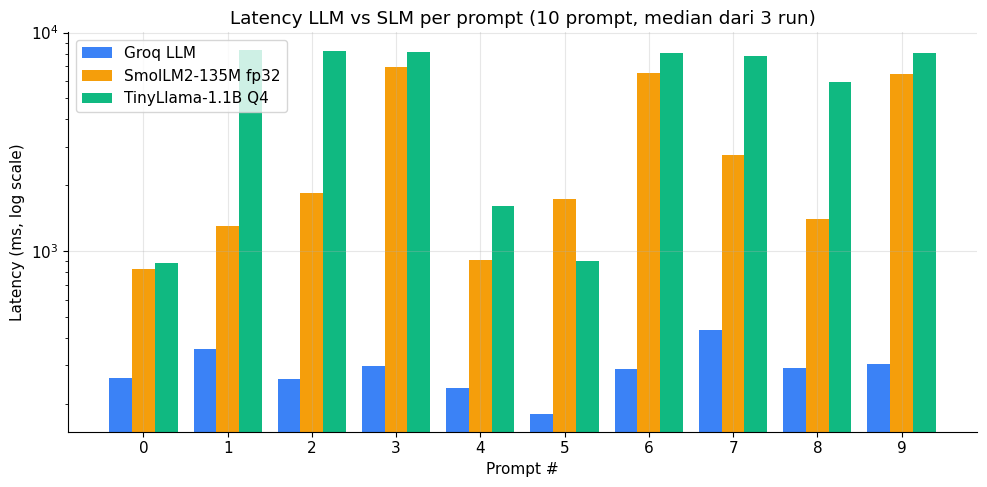

In [9]:
import matplotlib.pyplot as plt
import numpy as np

from utils.plotting import COLORS, setup_style
setup_style()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(PROMPTS))
width = 0.27

ax.bar(x - width, lat_pivot["groq_llm"], width, label="Groq LLM", color=COLORS["llm"])
ax.bar(x,         lat_pivot["smollm2_fp32"], width, label="SmolLM2-135M fp32", color=COLORS["slm_fp32"])
ax.bar(x + width, lat_pivot["tinyllama_q4"], width, label="TinyLlama-1.1B Q4", color=COLORS["slm_q4"])

ax.set_yscale("log")
ax.set_xlabel("Prompt #")
ax.set_ylabel("Latency (ms, log scale)")
ax.set_title("Latency LLM vs SLM per prompt (10 prompt, median dari 3 run)")
ax.set_xticks(x)
ax.legend()
plt.tight_layout()
plt.show()

## 7. Sample output side-by-side (1 prompt)

Angka latency saja nggak cukup — kualitas output juga penting. Lihat 1 prompt yang sama, 3 backend:

In [10]:
SAMPLE_IDX = 2  # "Jelaskan apa itu inflasi dalam 2 kalimat."
print(f"PROMPT: {PROMPTS[SAMPLE_IDX]}\n")
for backend_name in BACKENDS:
    text = df[(df.prompt_idx == SAMPLE_IDX) & (df.backend == backend_name)].iloc[0]["output_text"]
    lat = lat_pivot.iloc[SAMPLE_IDX][backend_name]
    print(f"--- {backend_name}  ({lat:.0f} ms)")
    print(text)
    print()

PROMPT: Jelaskan apa itu inflasi dalam 2 kalimat.

--- groq_llm  (259 ms)
Inflasi adalah fenomena ekonomi yang terjadi ketika harga-harga barang dan jasa meningkat secara signifikan dalam jangka

--- smollm2_fp32  (1852 ms)
Kalimat itu itu inflasi dalam 2 kalimat.

--- tinyllama_q4  (8215 ms)
Inflasi dalam 2 kalimat mengandungi 2 paragraf yang berisi 2 kata dalam 1 paragraf. Kata dalam 1 paragraf berisi 1 kata 



## Refleksi & insight

1. **Groq dominan di latency** (sering 5-30x lebih cepat dari SLM lokal CPU) karena hardware LPU. **Tapi bukan gratis** — tiap call ada biaya.
2. **TinyLlama Q4** biasanya **lebih cepat dari SmolLM2 fp32** untuk output panjang, walau params 8x lebih banyak. Quantization > compute scaling di CPU.
3. **SmolLM2-135M** kualitas Bahasa lemah; tapi gratis + privat + offline.
4. **Cost per 10 prompts di Groq biasanya < $0.001** — terlihat negligible. Tapi di scale 1M request/hari = ~$30-100/hari. Itu titik di mana SLM lokal mulai masuk hitungan.
5. **Angka absolut tidak portable** antar mesin — laptop kamu mungkin 2x lebih cepat/lambat dari laptop temenmu. Yang penting **ratio antar backend di mesin yang sama**.

## Latihan mandiri

1. Tambah backend ke-4: `llama-3.3-70b-versatile` di Groq (model lebih besar). Apakah ada prompt di mana model 70B benar-benar lebih bagus dari 8B?
2. Tambah kolom "qualitative score" — kasih nilai 1-5 manual untuk tiap output, lalu bandingkan **per dolar**: backend mana yang paling value-for-money untuk task mu?
3. Coba ganti `MAX_TOKENS=200` dan ulang. Apakah ratio latency berubah? (Jawaban: ya, output panjang nge-amplify gap antara hardware cepat vs lambat.)

## Lanjut

Modul 03: tunjukkan kasus di mana **SLM mengalahkan LLM** — fine-tuning DistilBERT di sentiment Bahasa: [../03-finetuning-praktis/01_finetune_distilbert_smsa.ipynb](../03-finetuning-praktis/01_finetune_distilbert_smsa.ipynb)